# where and how to place the filters 
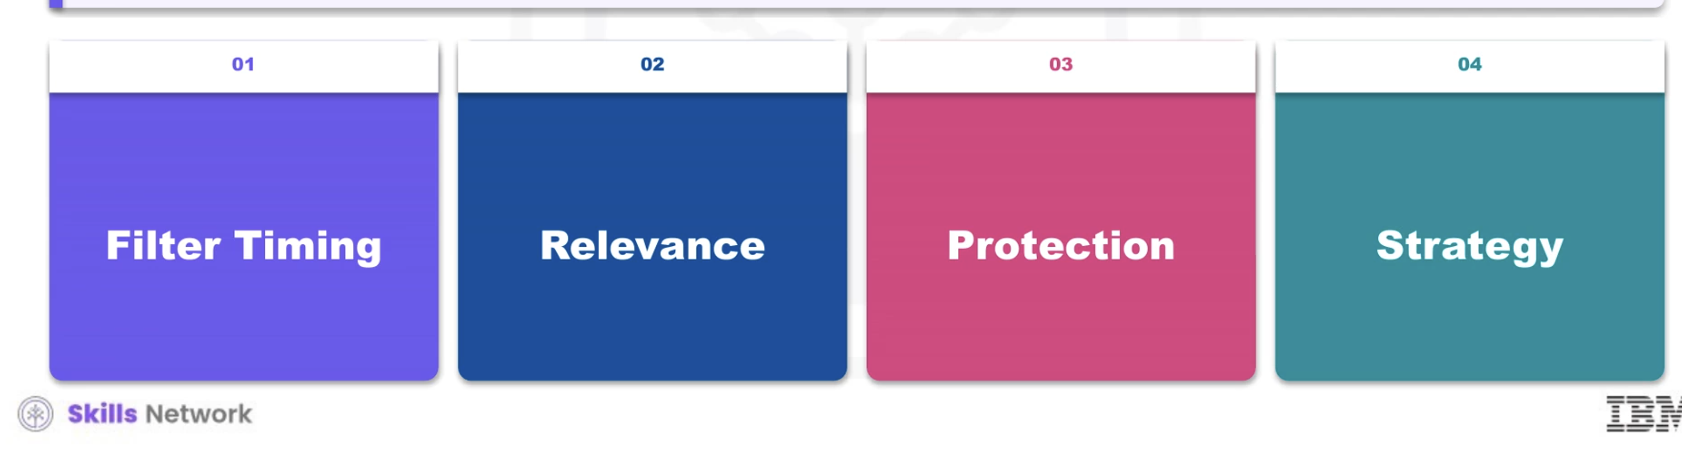
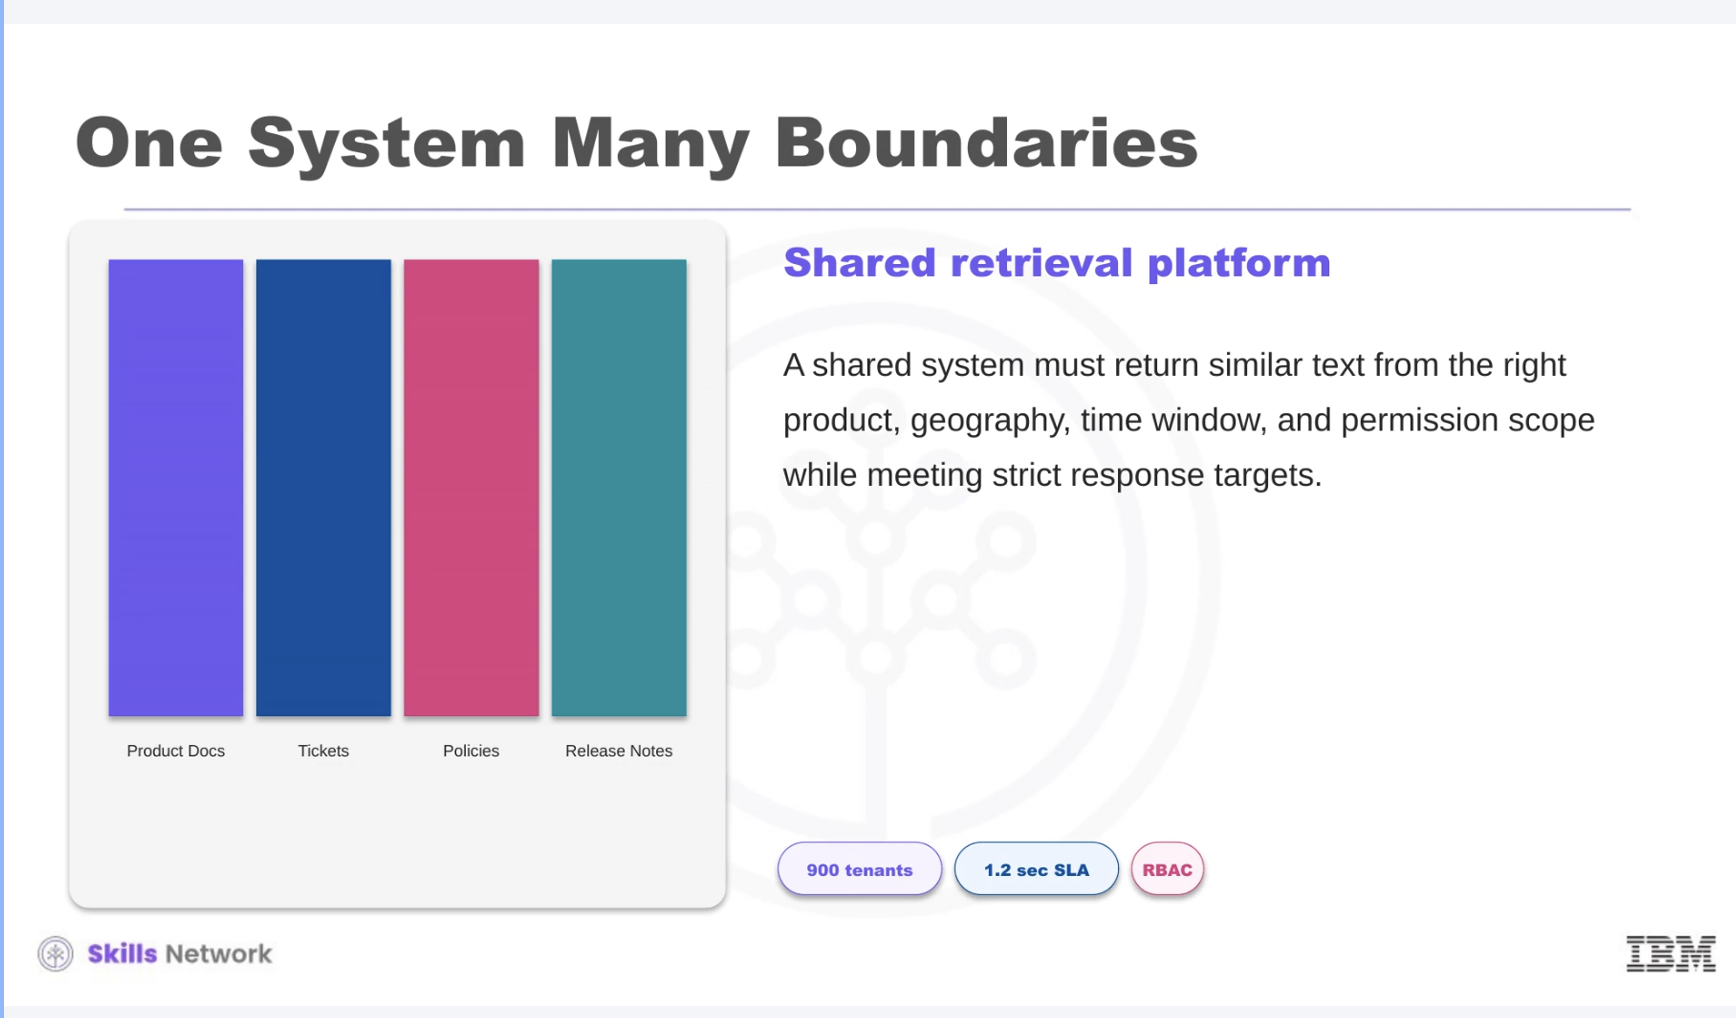
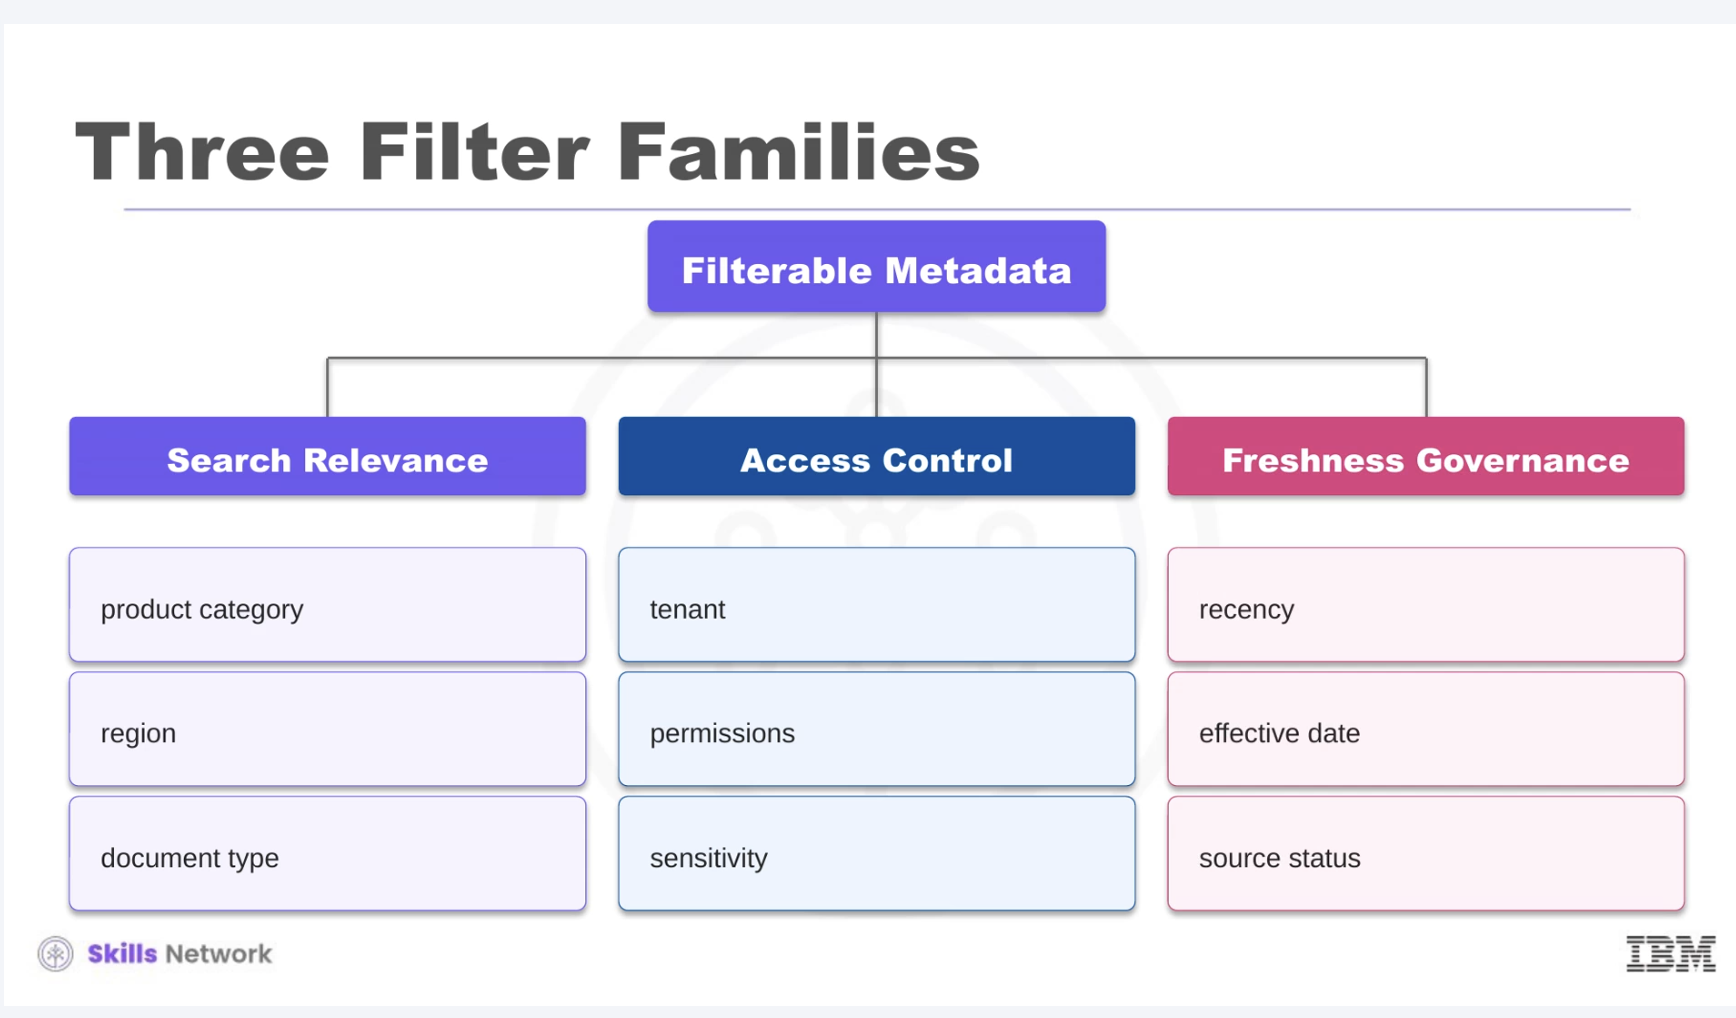
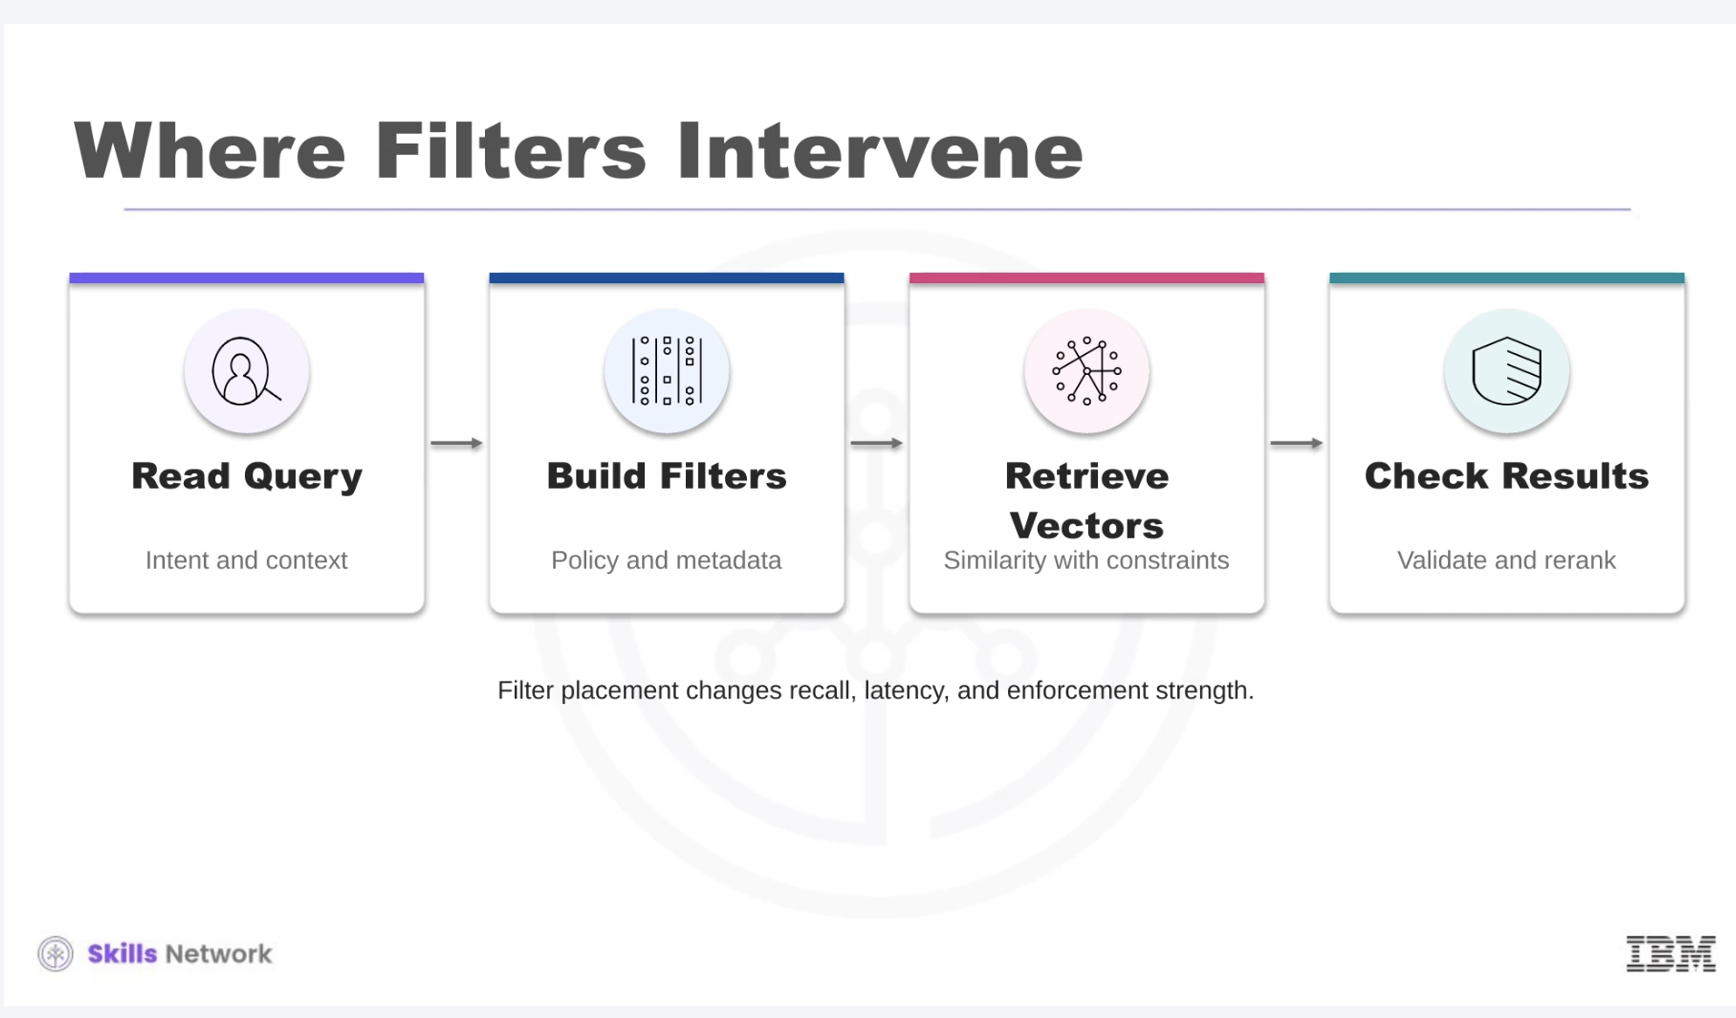

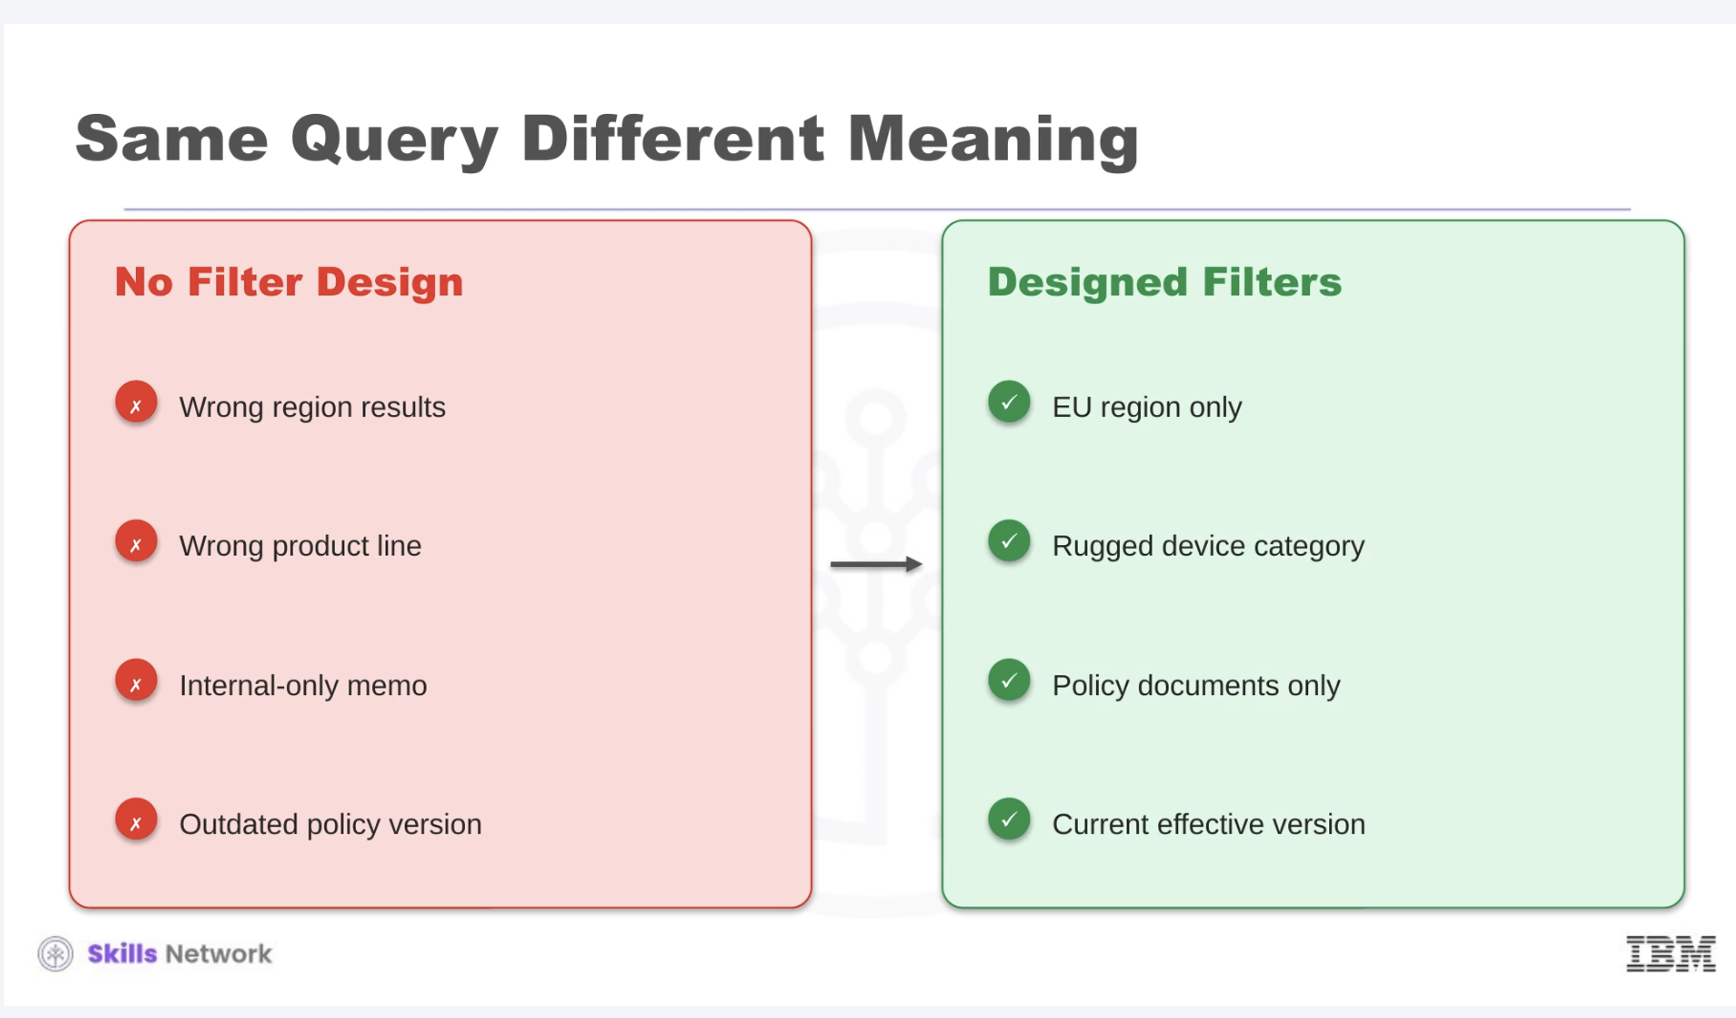
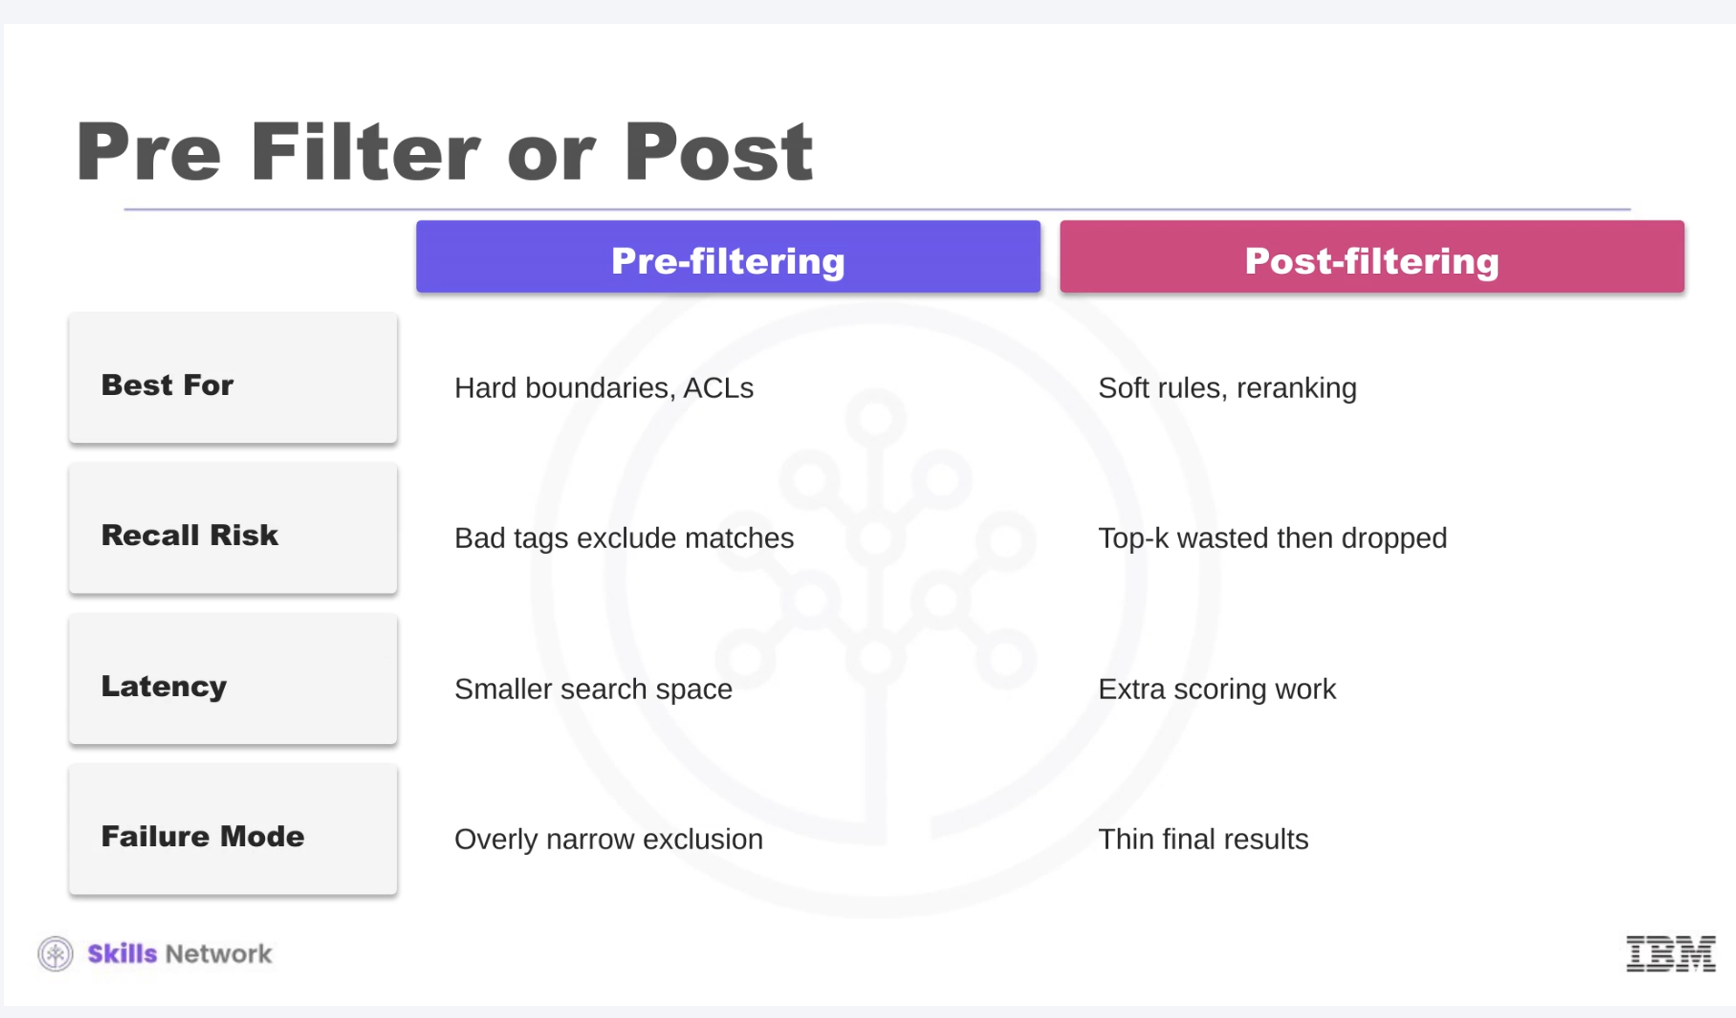
 <pre>1. Pre-filtering = filter BEFORE vector search
Imagine your database has:
100,000 vectors

User belongs to:
tenant_A

So before searching, you say:
Only search vectors where tenant_id = tenant_A

Then:
100,000 vectors
       ↓
tenant_id = tenant_A
       ↓
10,000 eligible vectors
       ↓
Vector similarity search
       ↓
Top results

Purpose: enforce hard boundaries.
This is what the slide means by:
Best for: Hard boundaries, ACLs

For your security project, this is extremely important.
If a document is not authorized, ideally it should never even become a candidate.
2. Post-filtering = search FIRST, filter AFTER
Here you do:
100,000 vectors
       ↓
Vector similarity search
       ↓
Top 20 results
       ↓
Apply metadata/security filter
       ↓
Remove unauthorized results
       ↓
Final results

So maybe:
Top 5 before filter:

doc-A  ← authorized
doc-B  ← unauthorized ❌
doc-C  ← unauthorized ❌
doc-D  ← authorized
doc-E  ← unauthorized ❌

After filtering:
doc-A
doc-D

The problem?
You searched for only the top 5, and 3 of them got thrown away.
You might end up with too few results.
That's what the slide means by:
Recall risk: Top-k wasted then dropped

So why would anyone use post-filtering?
Because not every filter is a hard security boundary.
Suppose you have a soft preference:
region = India

Maybe you prefer Indian documents, but it's okay to consider other documents and rerank them.
Then post-filtering/reranking can make sense.
The slide summarizes it as:
	Pre-filter	Post-filter
When?	Before search	After search
Main purpose	Hard constraints	Soft rules / reranking
Search space	Smaller	Larger
Main risk	Filtering too aggressively	Good results get discarded
Security/ACL	Very suitable	Riskier


The REALLY important part for your project
Think of your retrieval system as having two different kinds of checks.
Hard security constraint
tenant_id
access_group
sensitivity_label

You don't want:
"Let's retrieve it first and check permission later."

You want:
User
 ↓
Authentication
 ↓
Determine user's permissions
 ↓
PRE-FILTER
 ↓
Vector retrieval
 ↓
Relevant authorized candidates

Because if the user isn't allowed to access something, relevance doesn't matter.
Soft relevance constraint
Something like:
region
product
topic
language

could potentially be used as retrieval/reranking criteria depending on the architecture.
So the mental model I'd keep is:
             USER QUERY
                  ↓
       ┌────────────────────┐
       │ HARD SECURITY      │
       │ PRE-FILTER         │
       │ tenant / ACL       │
       └────────────────────┘
                  ↓
          Vector Retrieval
                  ↓
       ┌────────────────────┐
       │ SOFT / RELEVANCE   │
       │ FILTER / RERANK    │
       └────────────────────┘
                  ↓
              LLM

Pre-filtering answers:  
"What data am I even allowed to search?"

Post-filtering answers:  
"Among what I found, which results should I keep/rerank?"

That's the purpose of the two.</pre>

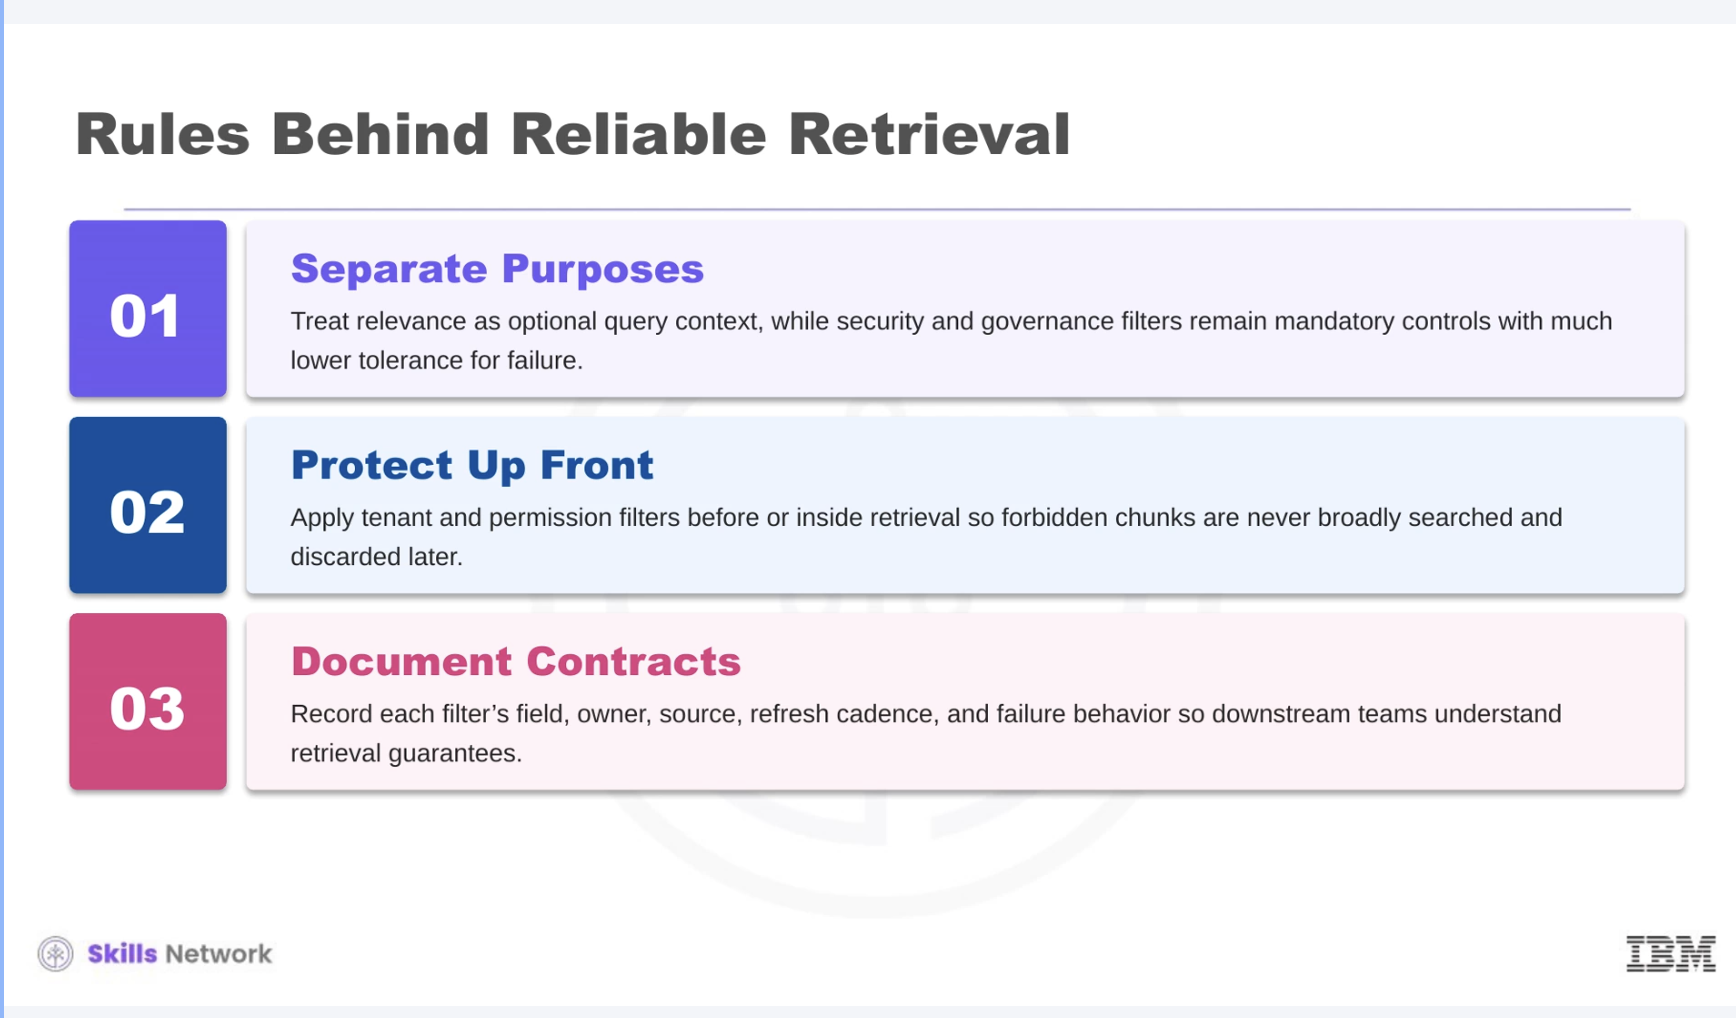



# ***Hands On Virtual lab:***

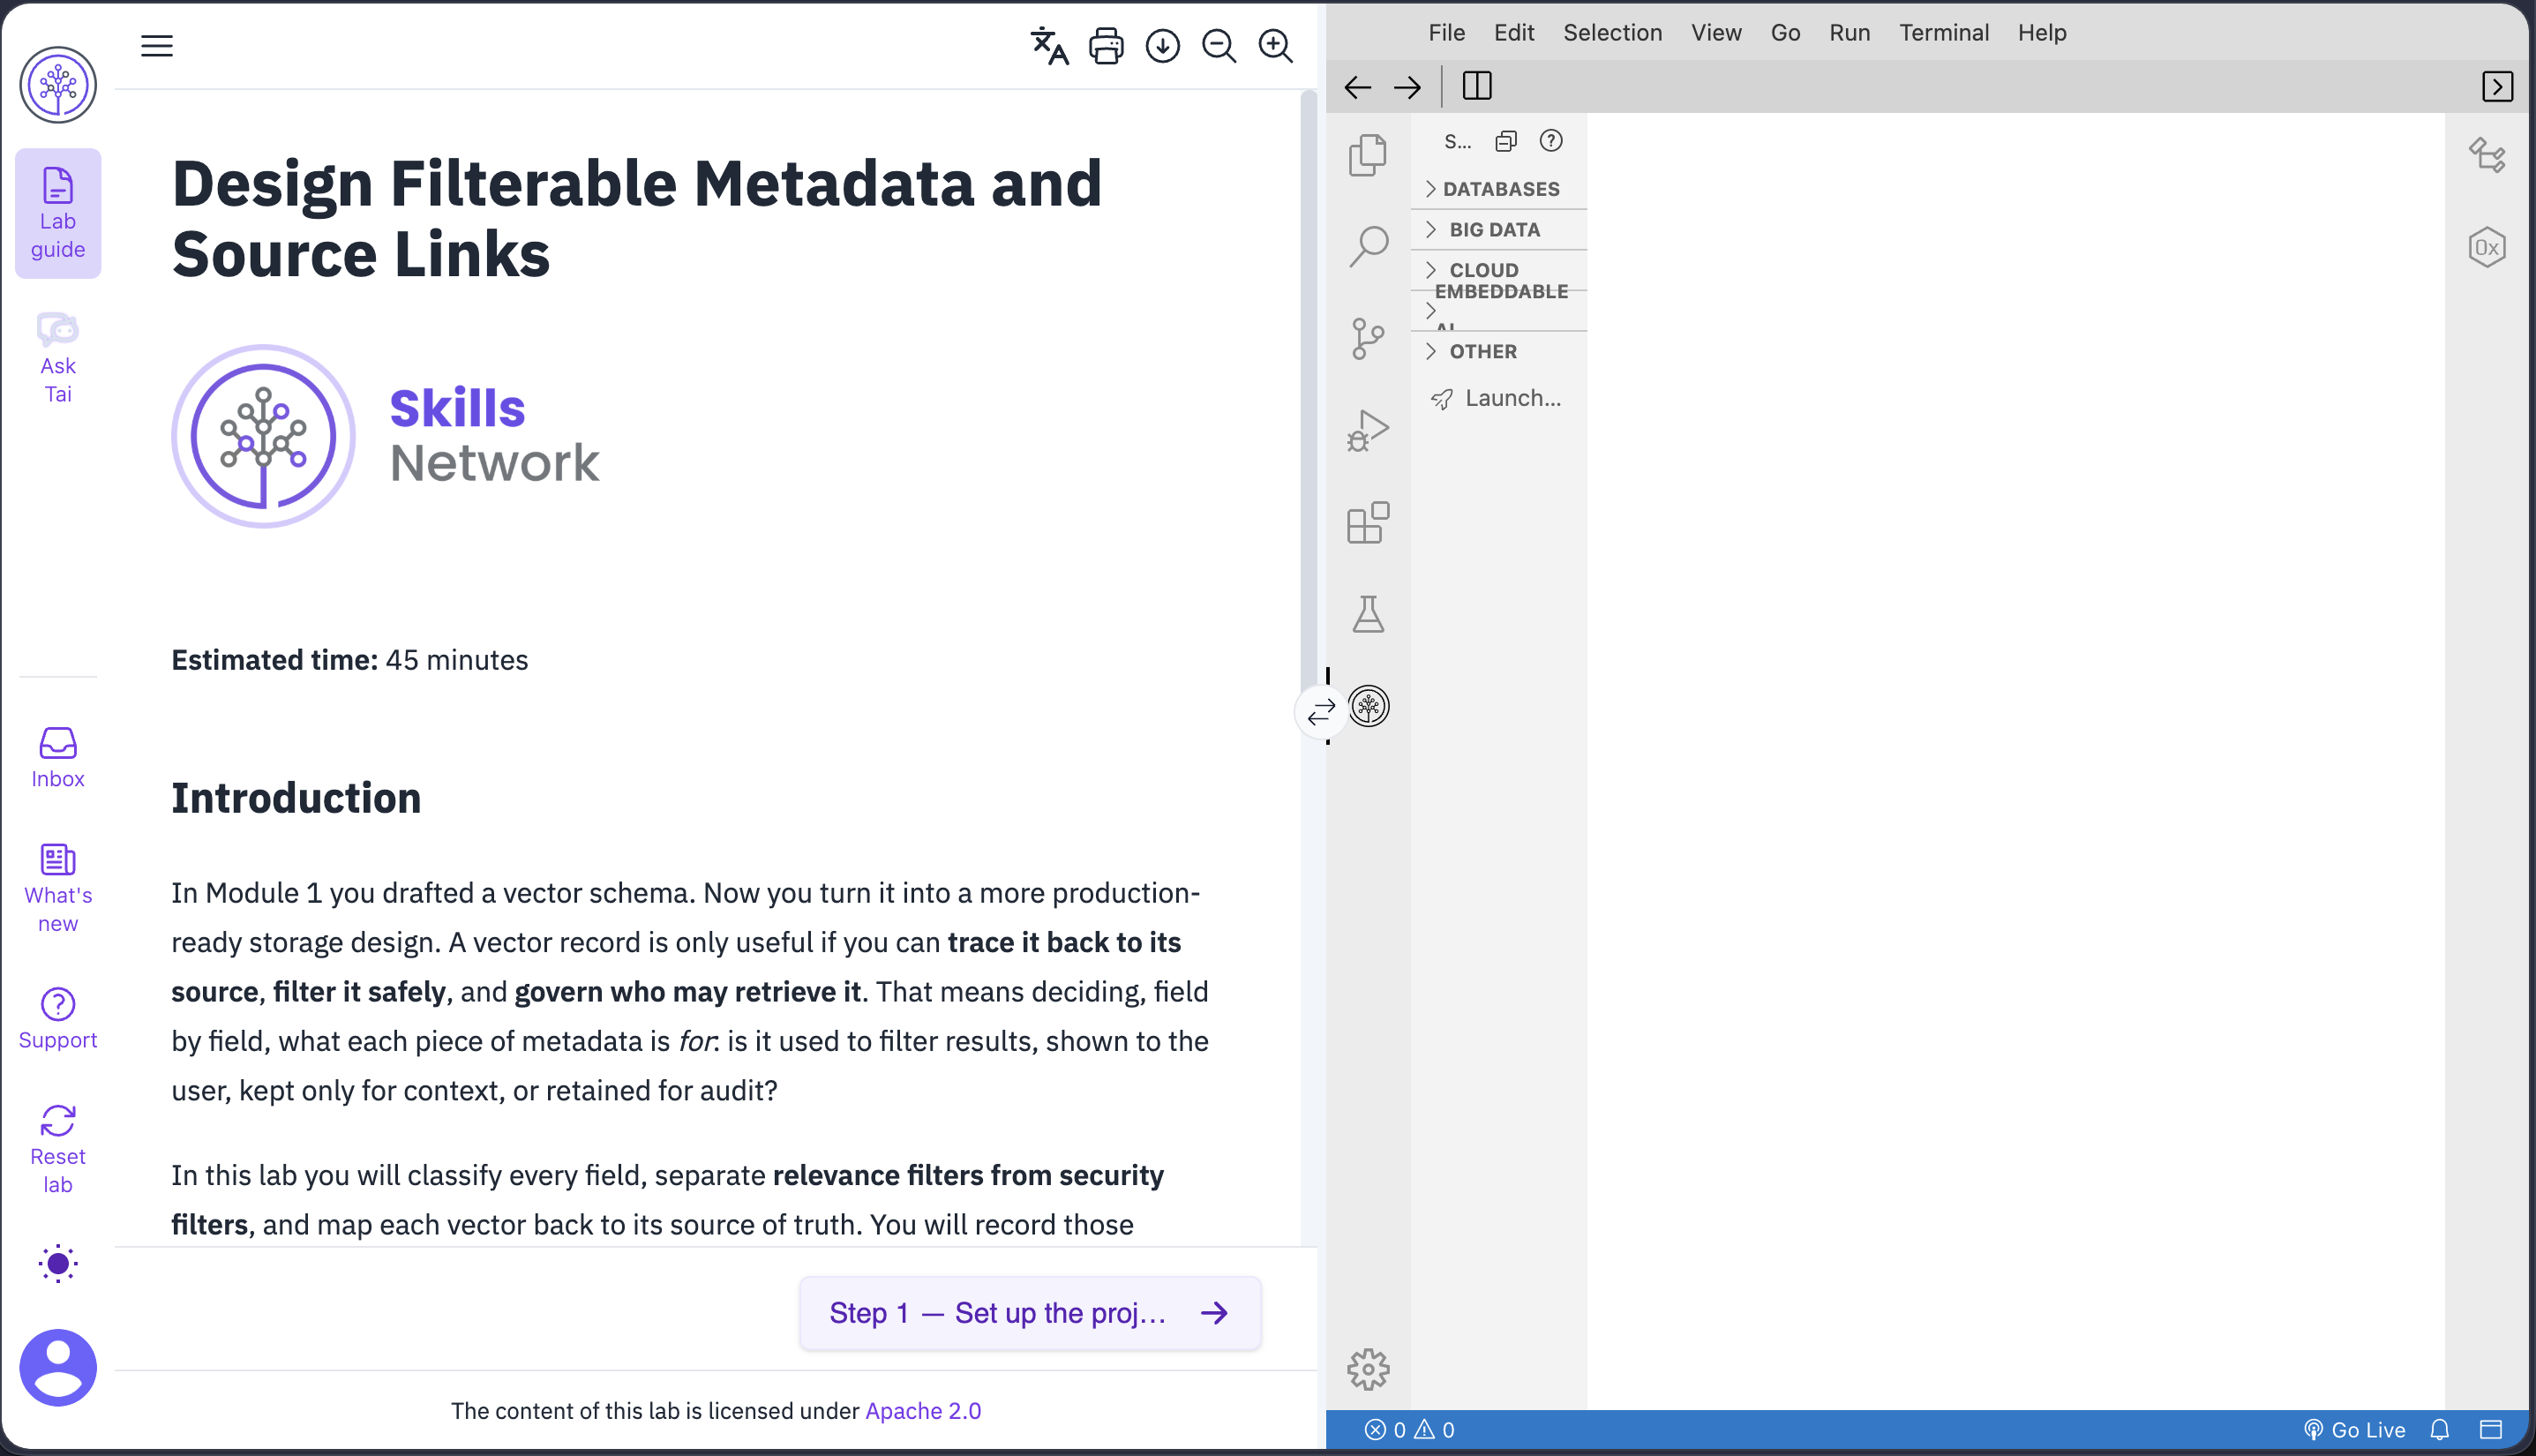

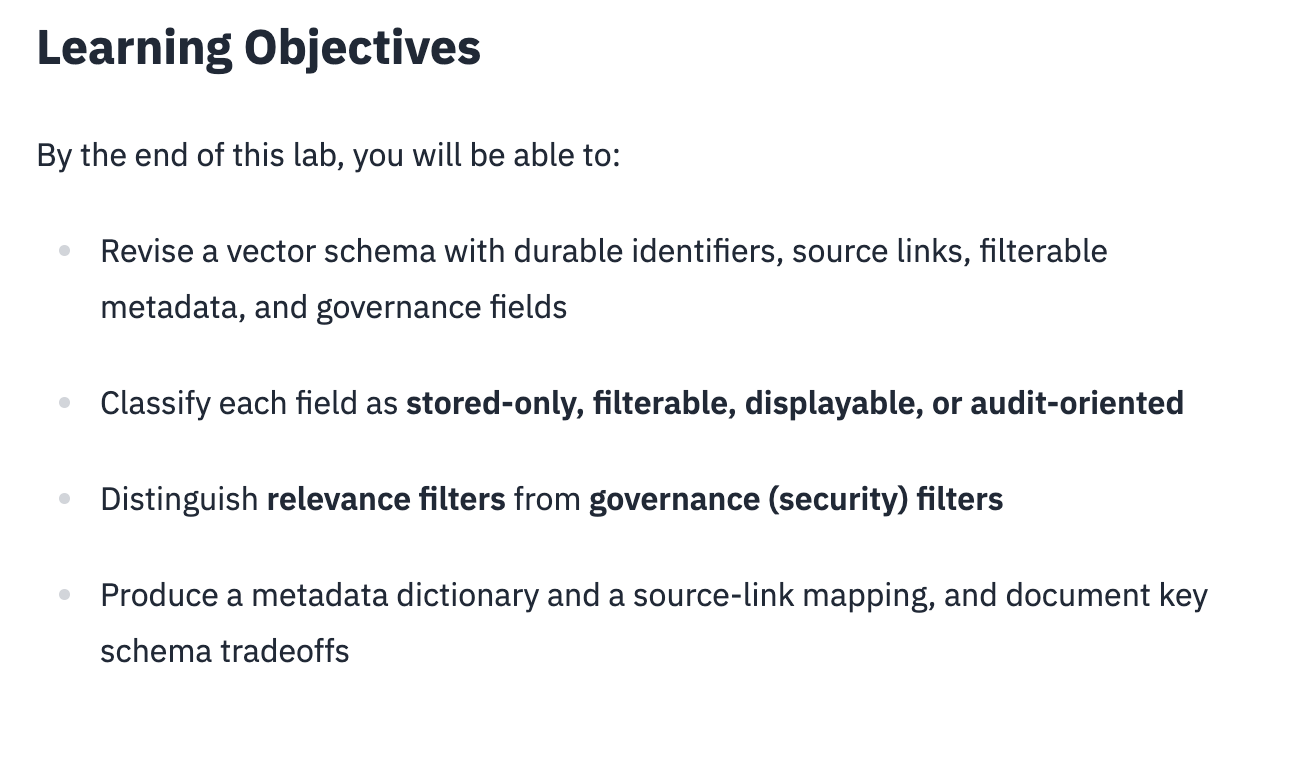

# Go to the Proj for the implementation details

# [VectordbDesign](Practical1/VectordbDesign.py)

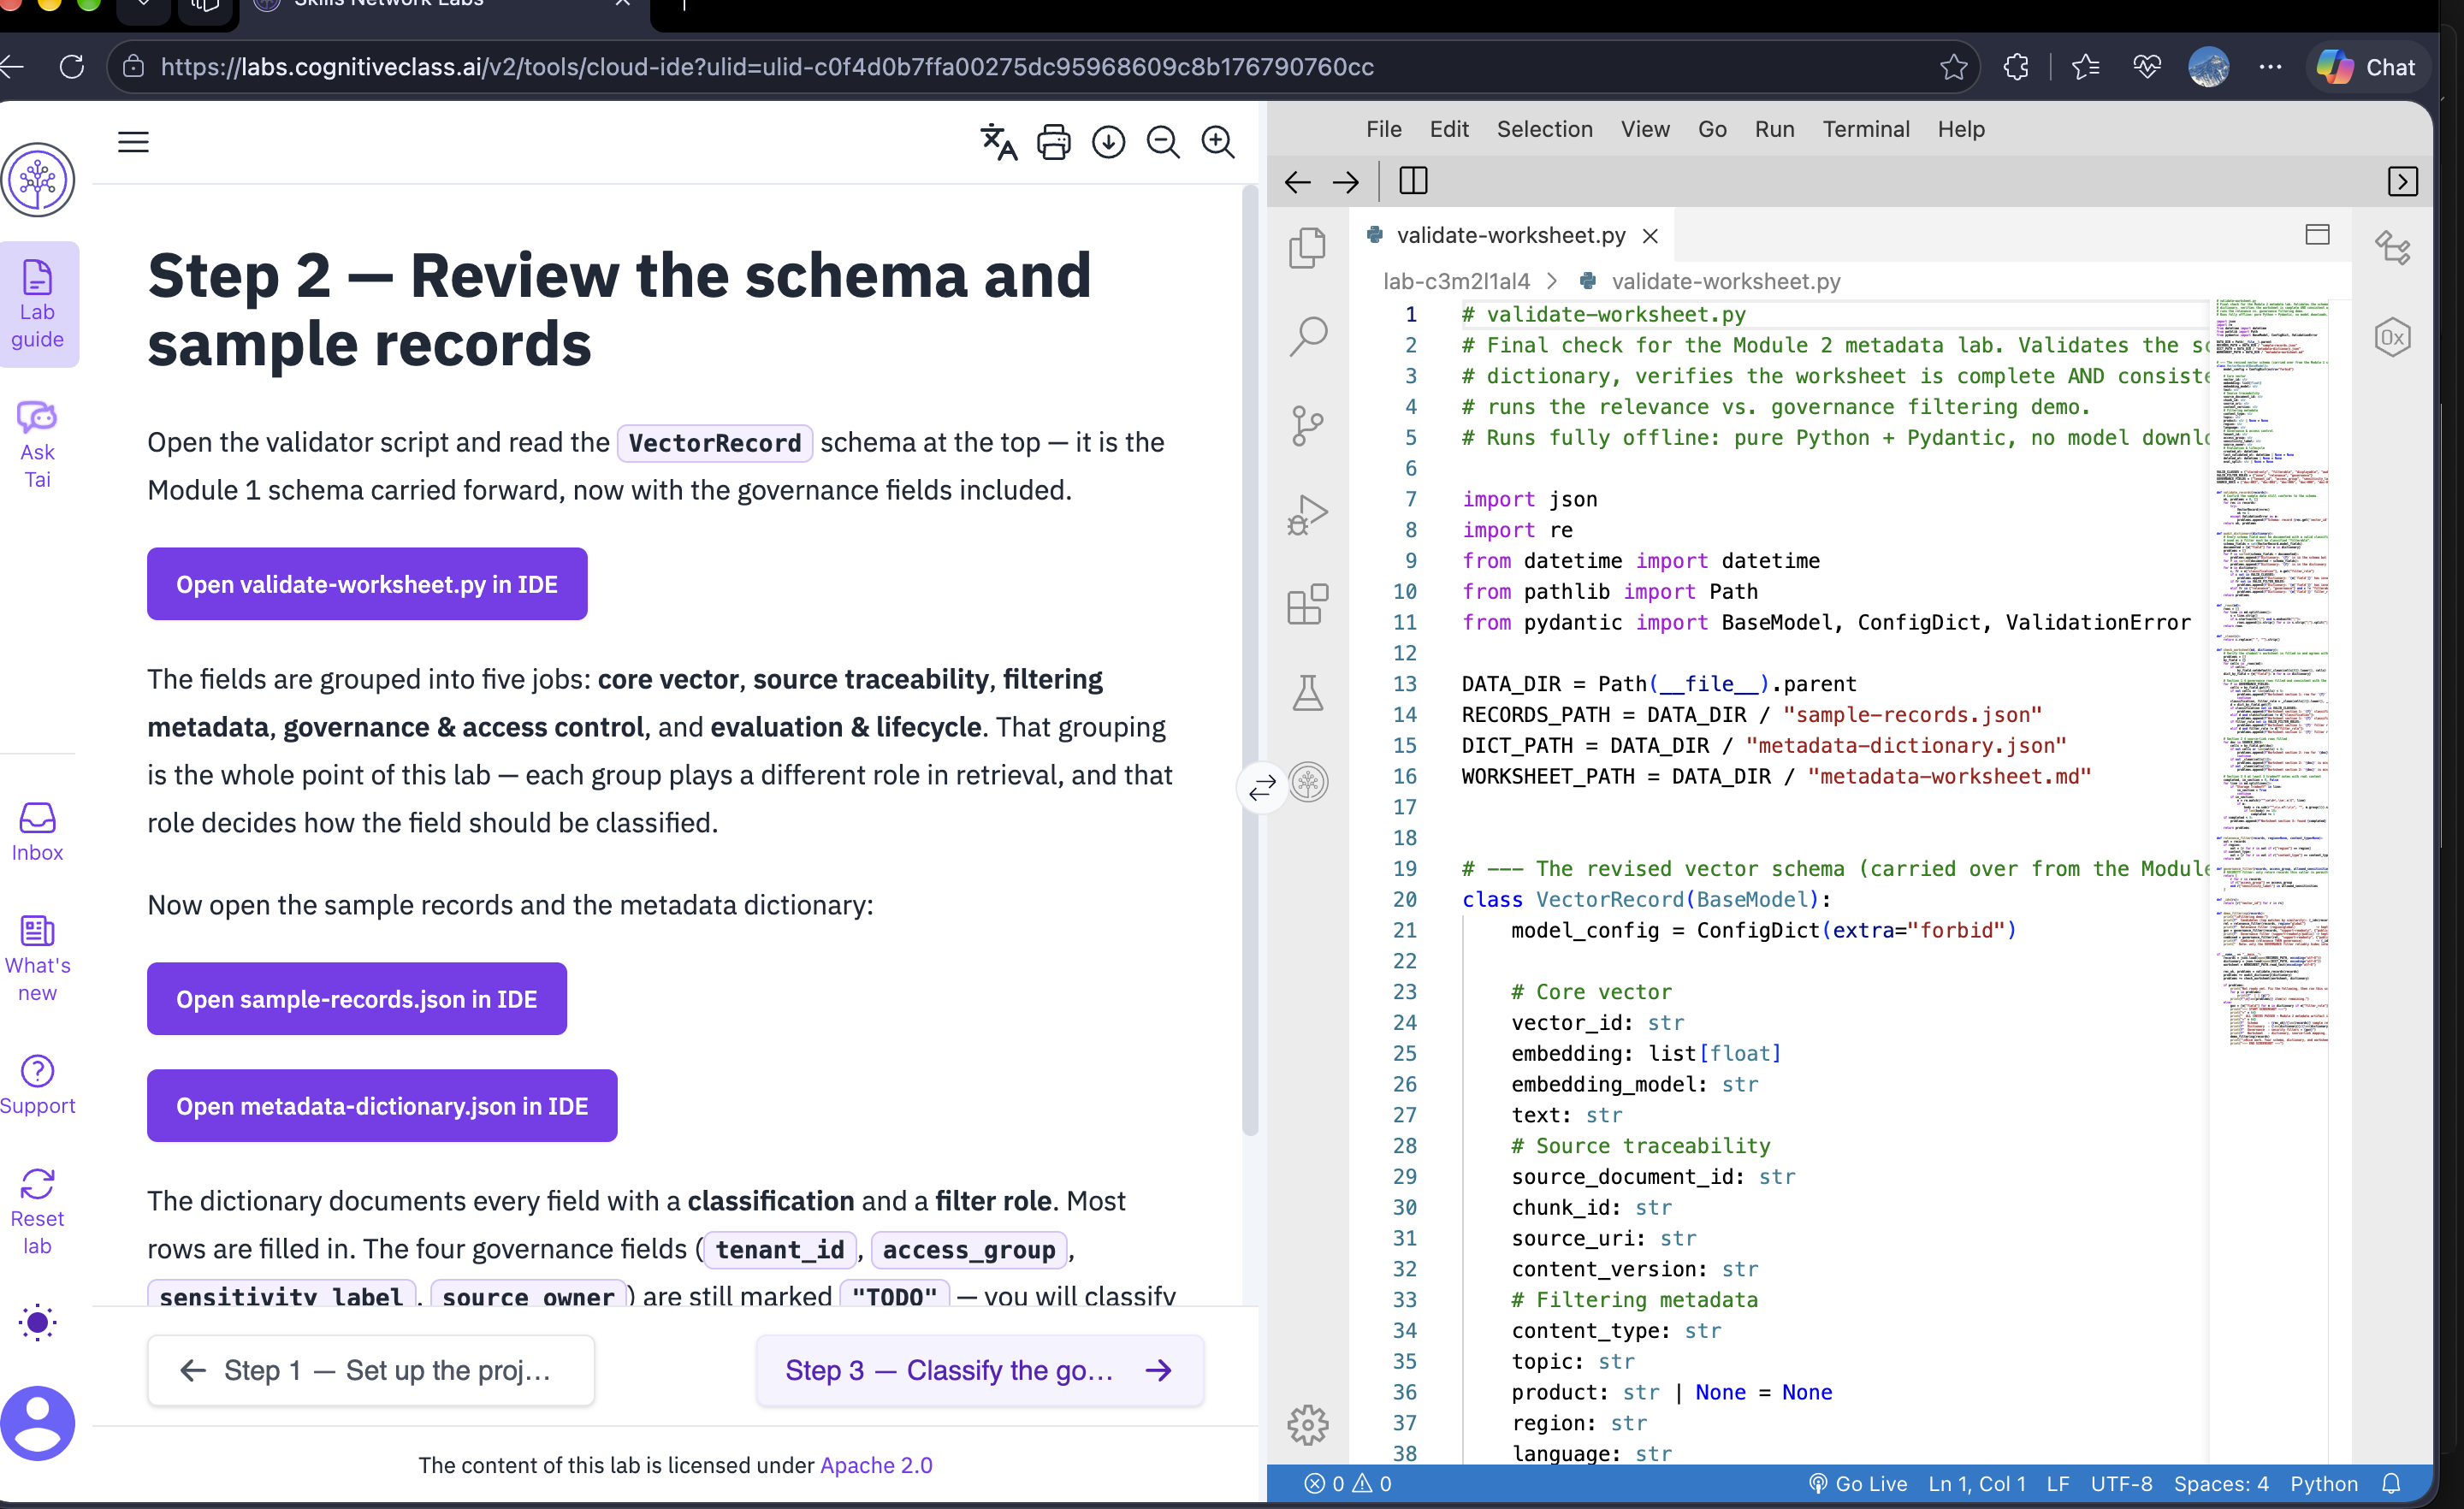
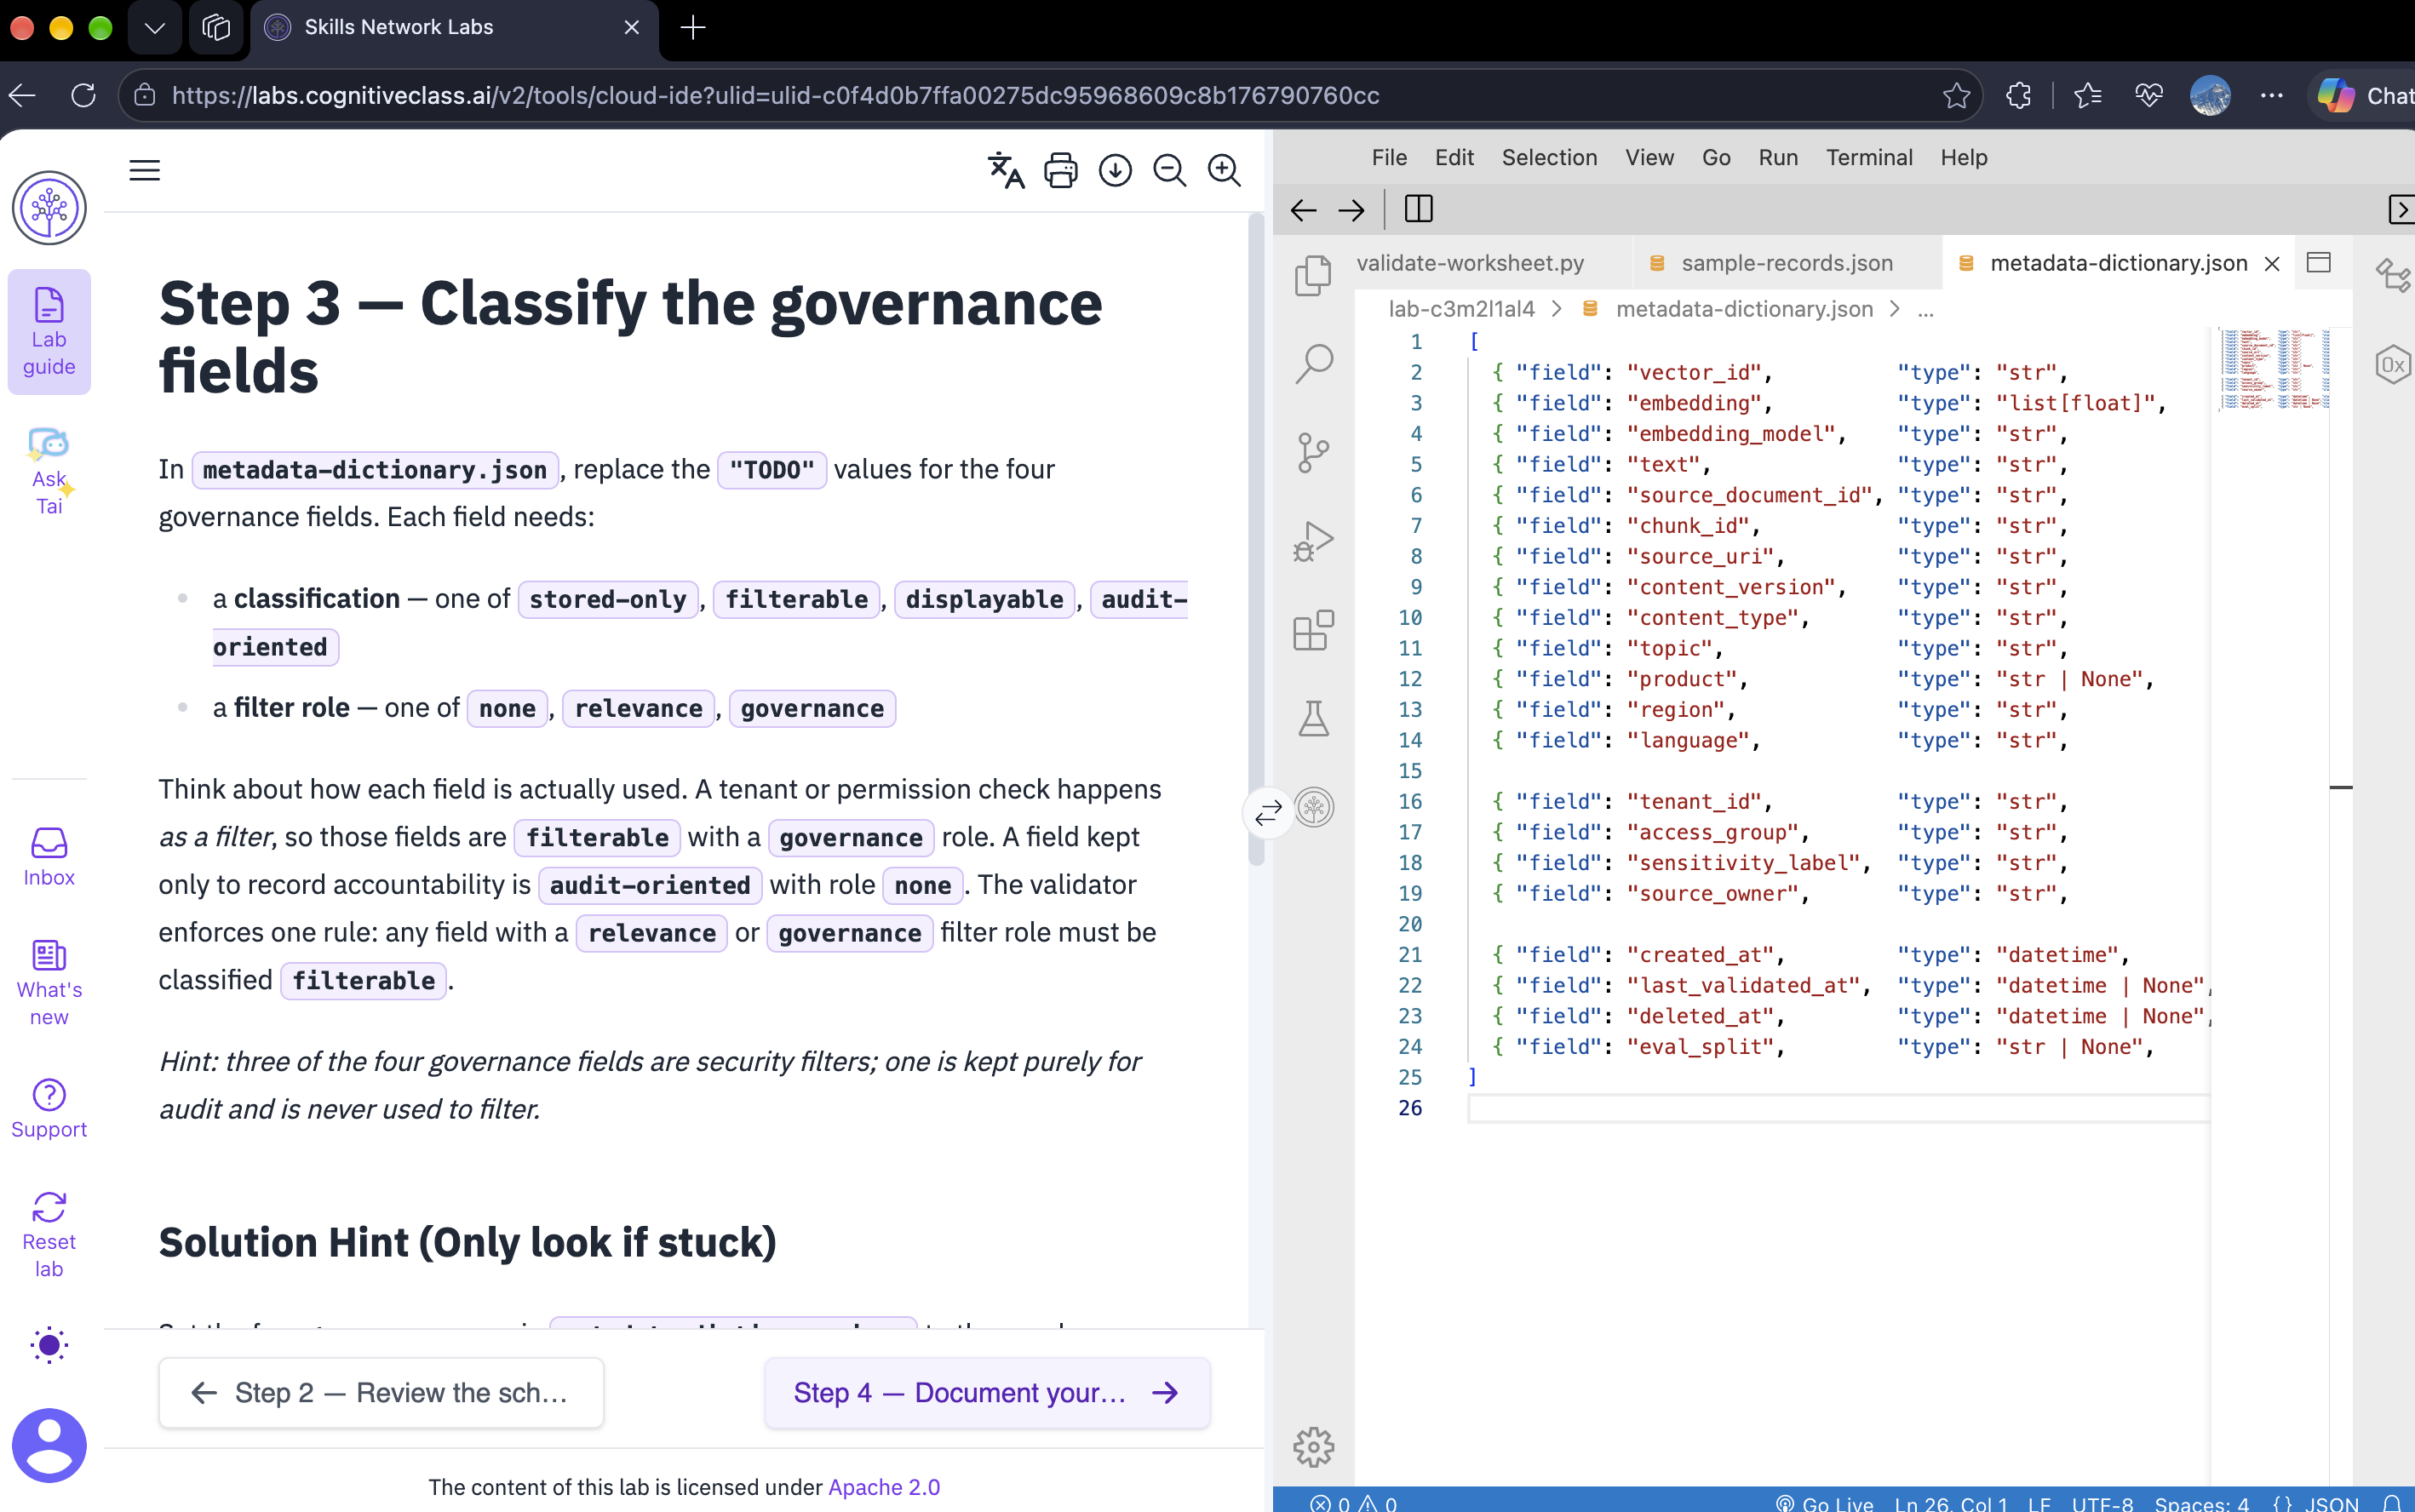


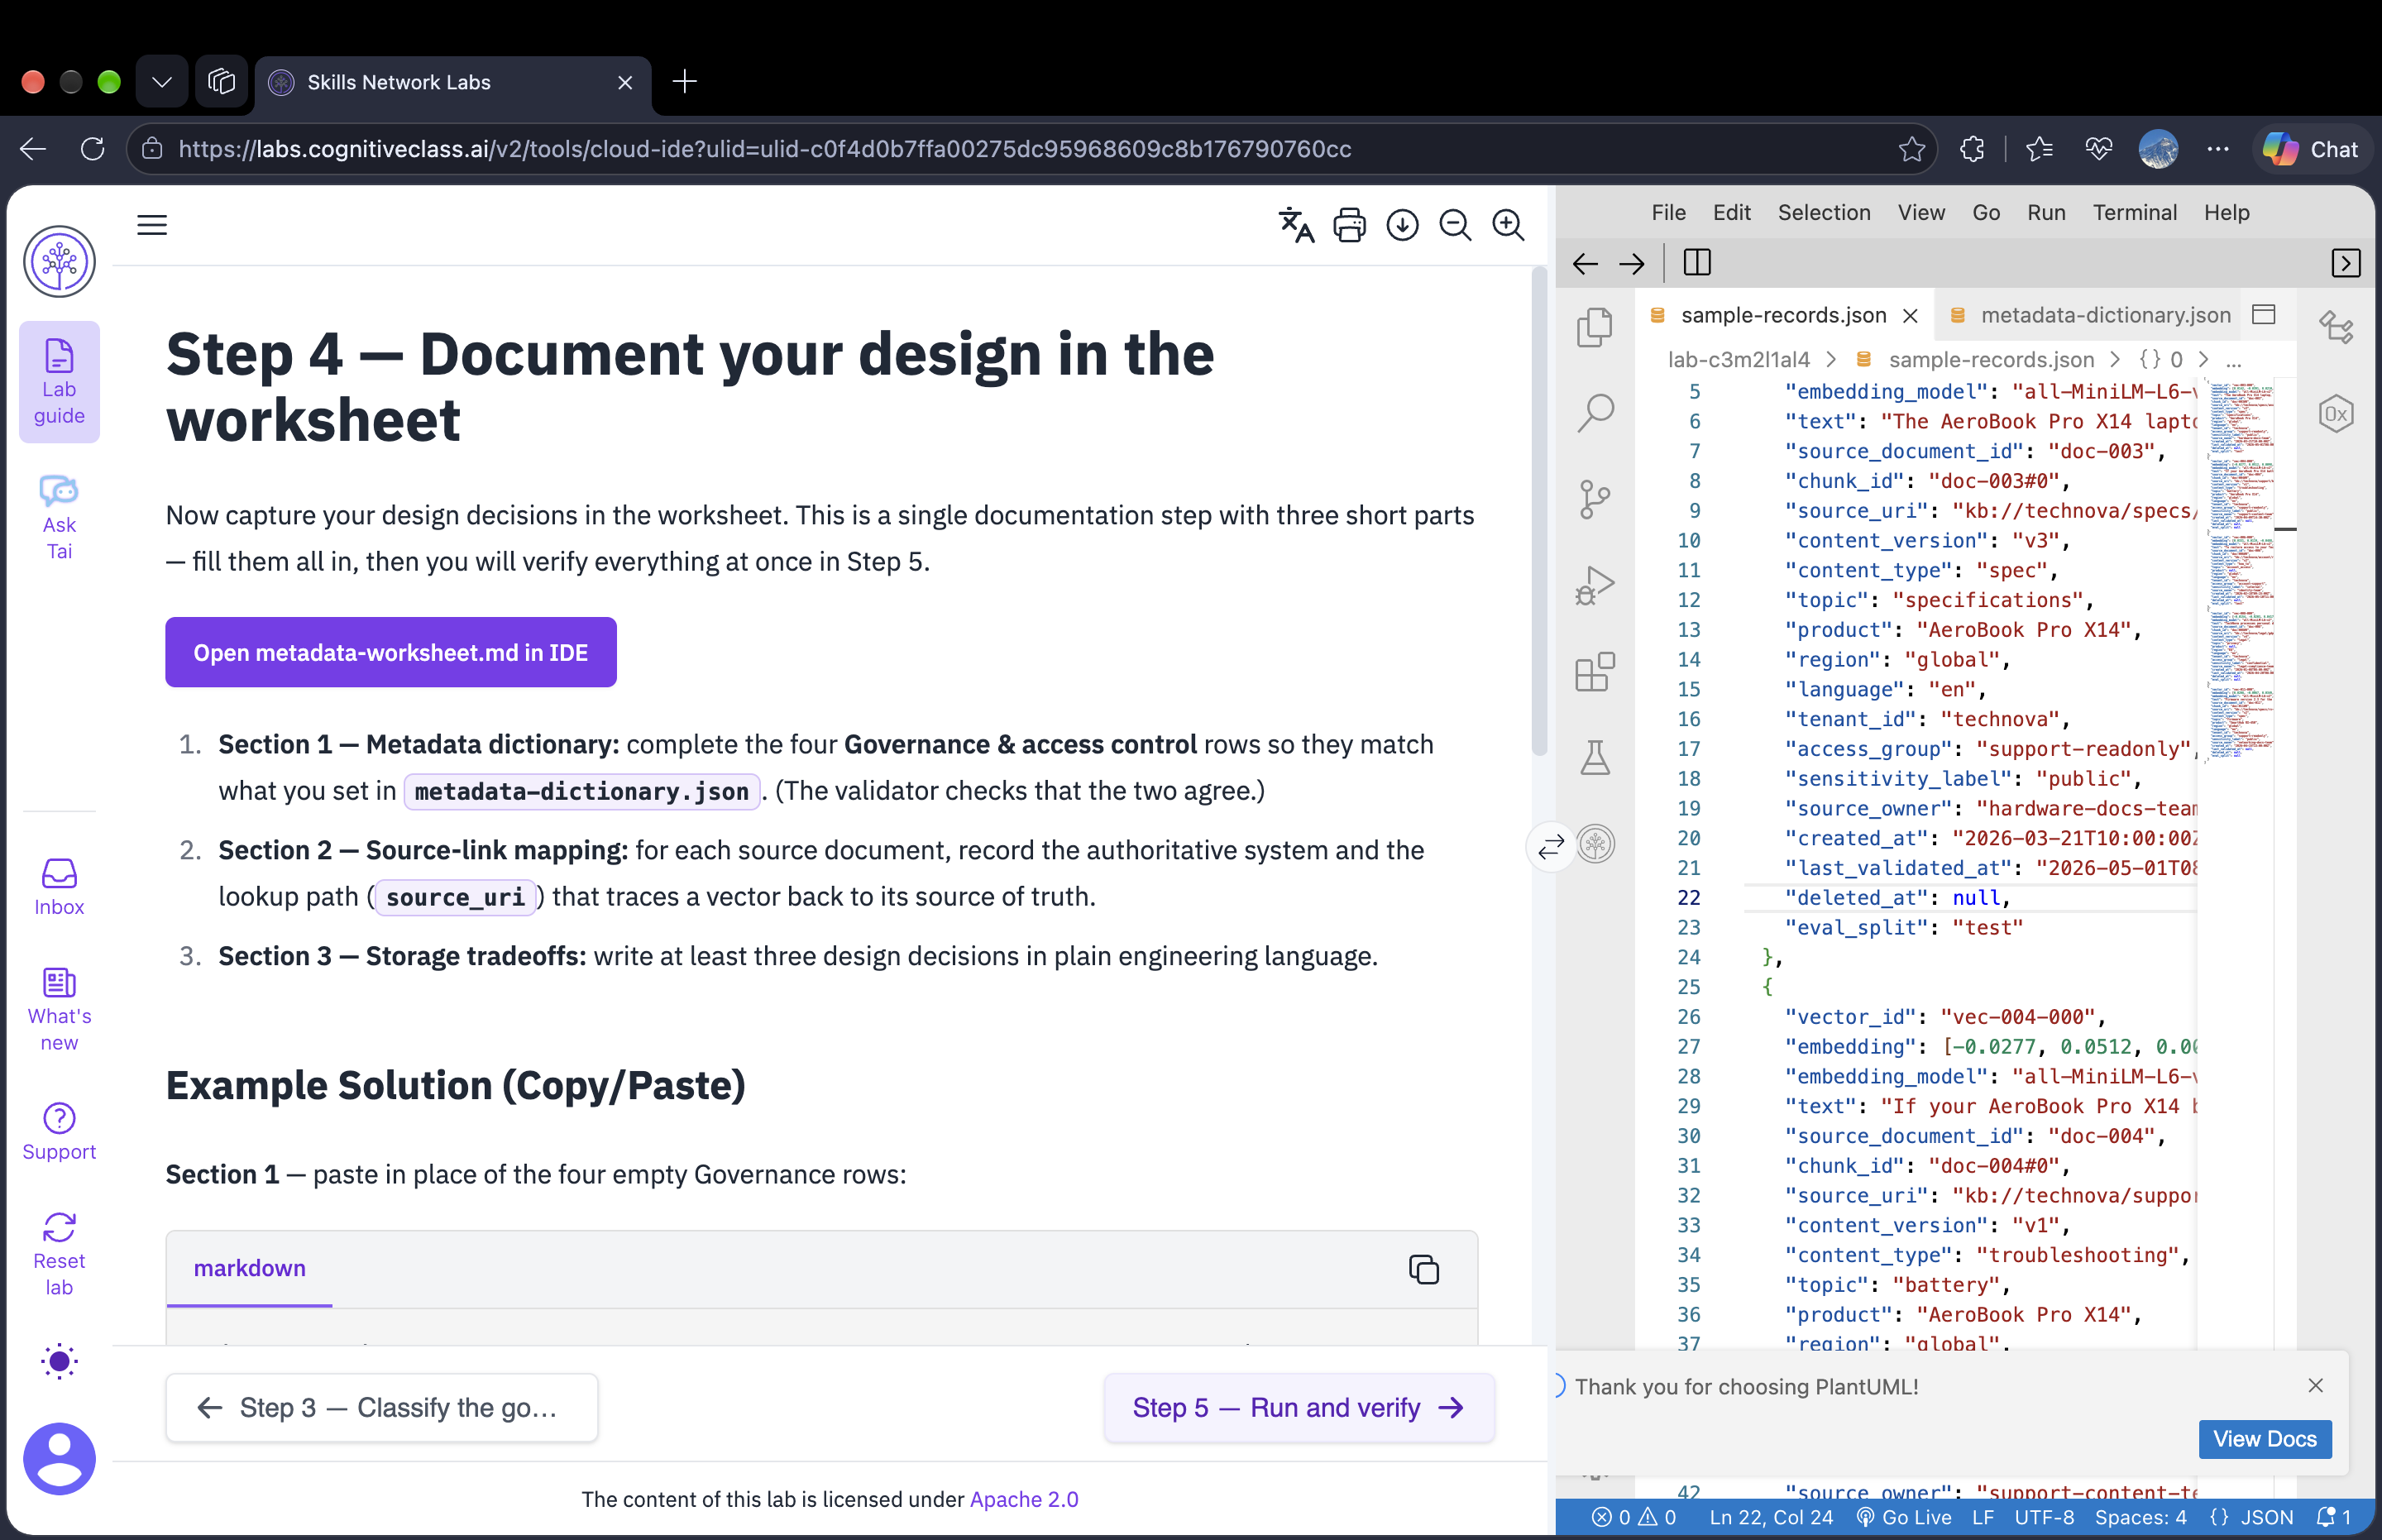

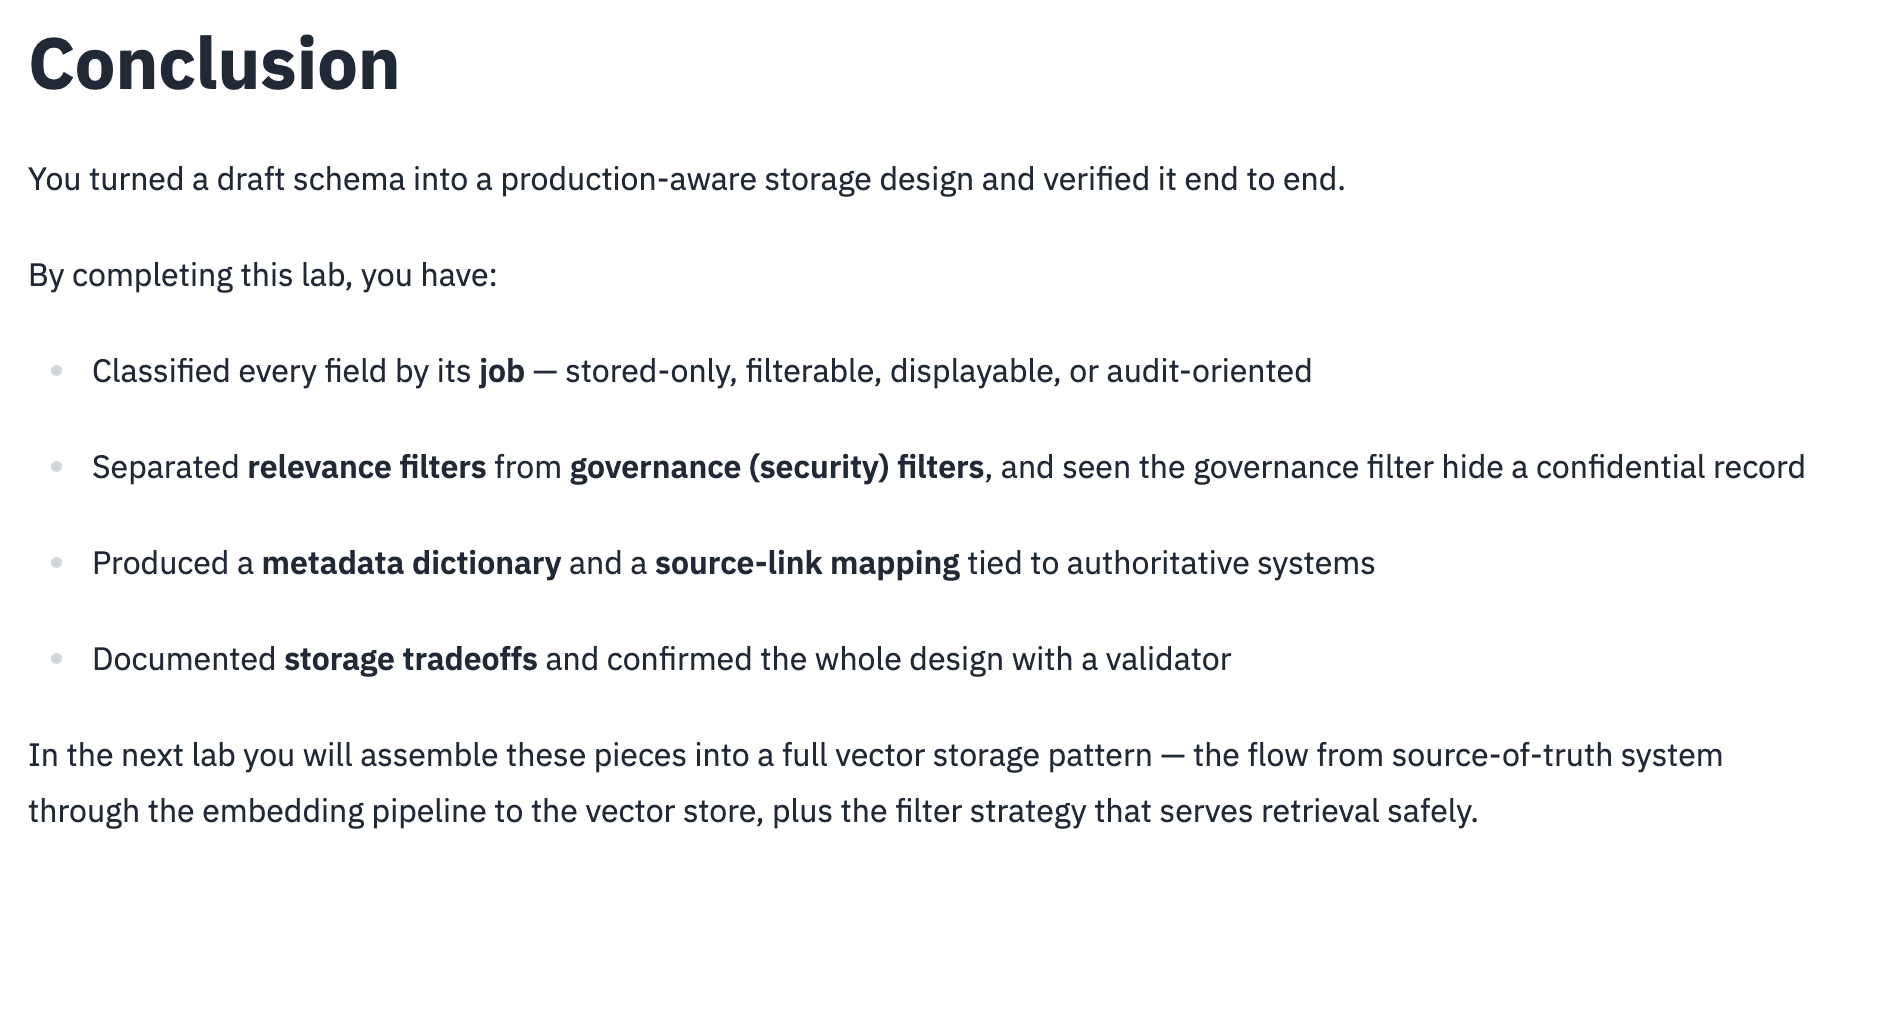